# Лабораторная работа 10 — Деревья решений и случайный лес

**Цель работы:** обучить модели дерева решений и случайного леса на датасете GTZAN, оценить качество классификации с помощью confusion matrix и ROC-анализа.

## Теоретическое введение

### Дерево решений (Decision Tree)

Дерево решений — интерпретируемая модель классификации, которая разбивает пространство признаков на области с помощью последовательных условий вида «если признак $x_j \leq t$». Алгоритм **CART** (Classification and Regression Trees) строит бинарное дерево, выбирая на каждом шаге признак и порог, максимизирующие «чистоту» разбиения.

**Критерии расщепления:**

- **Критерий Джини** (Gini impurity): $G = 1 - \sum_{k=1}^{K} p_k^2$, где $p_k$ — доля класса $k$ в узле. Gini = 0 означает, что узел содержит только один класс.

- **Энтропия** (Information Gain): $H = -\sum_{k=1}^{K} p_k \log_2(p_k)$. Чем ниже энтропия, тем «чище» узел.

Главная проблема деревьев — **переобучение**: без ограничений дерево вырастает до чистых листьев на обучающей выборке, но плохо обобщает. Контролировать сложность можно параметром `max_depth`.

### Случайный лес (Random Forest)

Случайный лес — **ансамбль** деревьев решений, объединяющий два механизма:

1. **Бэггинг** (Bootstrap Aggregating) — каждое дерево обучается на случайной подвыборке данных (с возвратом)
2. **Случайный отбор признаков** — в каждом узле рассматривается только подмножество из $\sqrt{p}$ признаков

Благодаря этому деревья в лесу слабо коррелированы, а их усреднение снижает дисперсию и повышает устойчивость модели. Побочный бонус — **Out-of-Bag (OOB) оценка**: примеры, не попавшие в бутстрэп-выборку дерева, используются для оценки без отдельной тестовой выборки.

Случайный лес также позволяет оценить **важность признаков** (feature importance) — насколько каждый признак снижает impurity при расщеплениях.

## 1. Загрузка и обзор данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, roc_auc_score, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df.shape}')
print(f'Жанры: {df["label"].unique()}')
print(f'По {df["label"].value_counts().iloc[0]} треков на жанр')
df.head()

Размер датасета: (1000, 60)
Жанры: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
По 100 треков на жанр


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## 2. Предобработка данных

Деревья решений формально не требуют масштабирования, но для корректного сравнения с другими методами и для ROC-анализа масштабируем данные.

In [3]:
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Признаков: {X.shape[1]}')
print(f'Обучающая выборка: {X_train.shape[0]}, Тестовая: {X_test.shape[0]}')

Признаков: 57
Обучающая выборка: 800, Тестовая: 200


## 3. Дерево решений

Обучим дерево решений с ограниченной глубиной `max_depth=5` для предотвращения переобучения и визуализируем его структуру.

In [35]:
dt_clf = DecisionTreeClassifier(max_depth=200, random_state=42, criterion='gini')
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy дерева решений: {acc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Accuracy дерева решений: 0.5050

              precision    recall  f1-score   support

       blues       0.47      0.35      0.40        20
   classical       0.74      0.85      0.79        20
     country       0.55      0.30      0.39        20
       disco       0.33      0.35      0.34        20
      hiphop       0.42      0.55      0.48        20
        jazz       0.50      0.60      0.55        20
       metal       0.87      0.65      0.74        20
         pop       0.57      0.60      0.59        20
      reggae       0.32      0.40      0.36        20
        rock       0.42      0.40      0.41        20

    accuracy                           0.51       200
   macro avg       0.52      0.51      0.50       200
weighted avg       0.52      0.51      0.50       200



### 3.1 Визуализация дерева решений

Одно из главных преимуществ деревьев — наглядная интерпретируемость. Каждый узел показывает условие разбиения, критерий Джини и распределение классов.

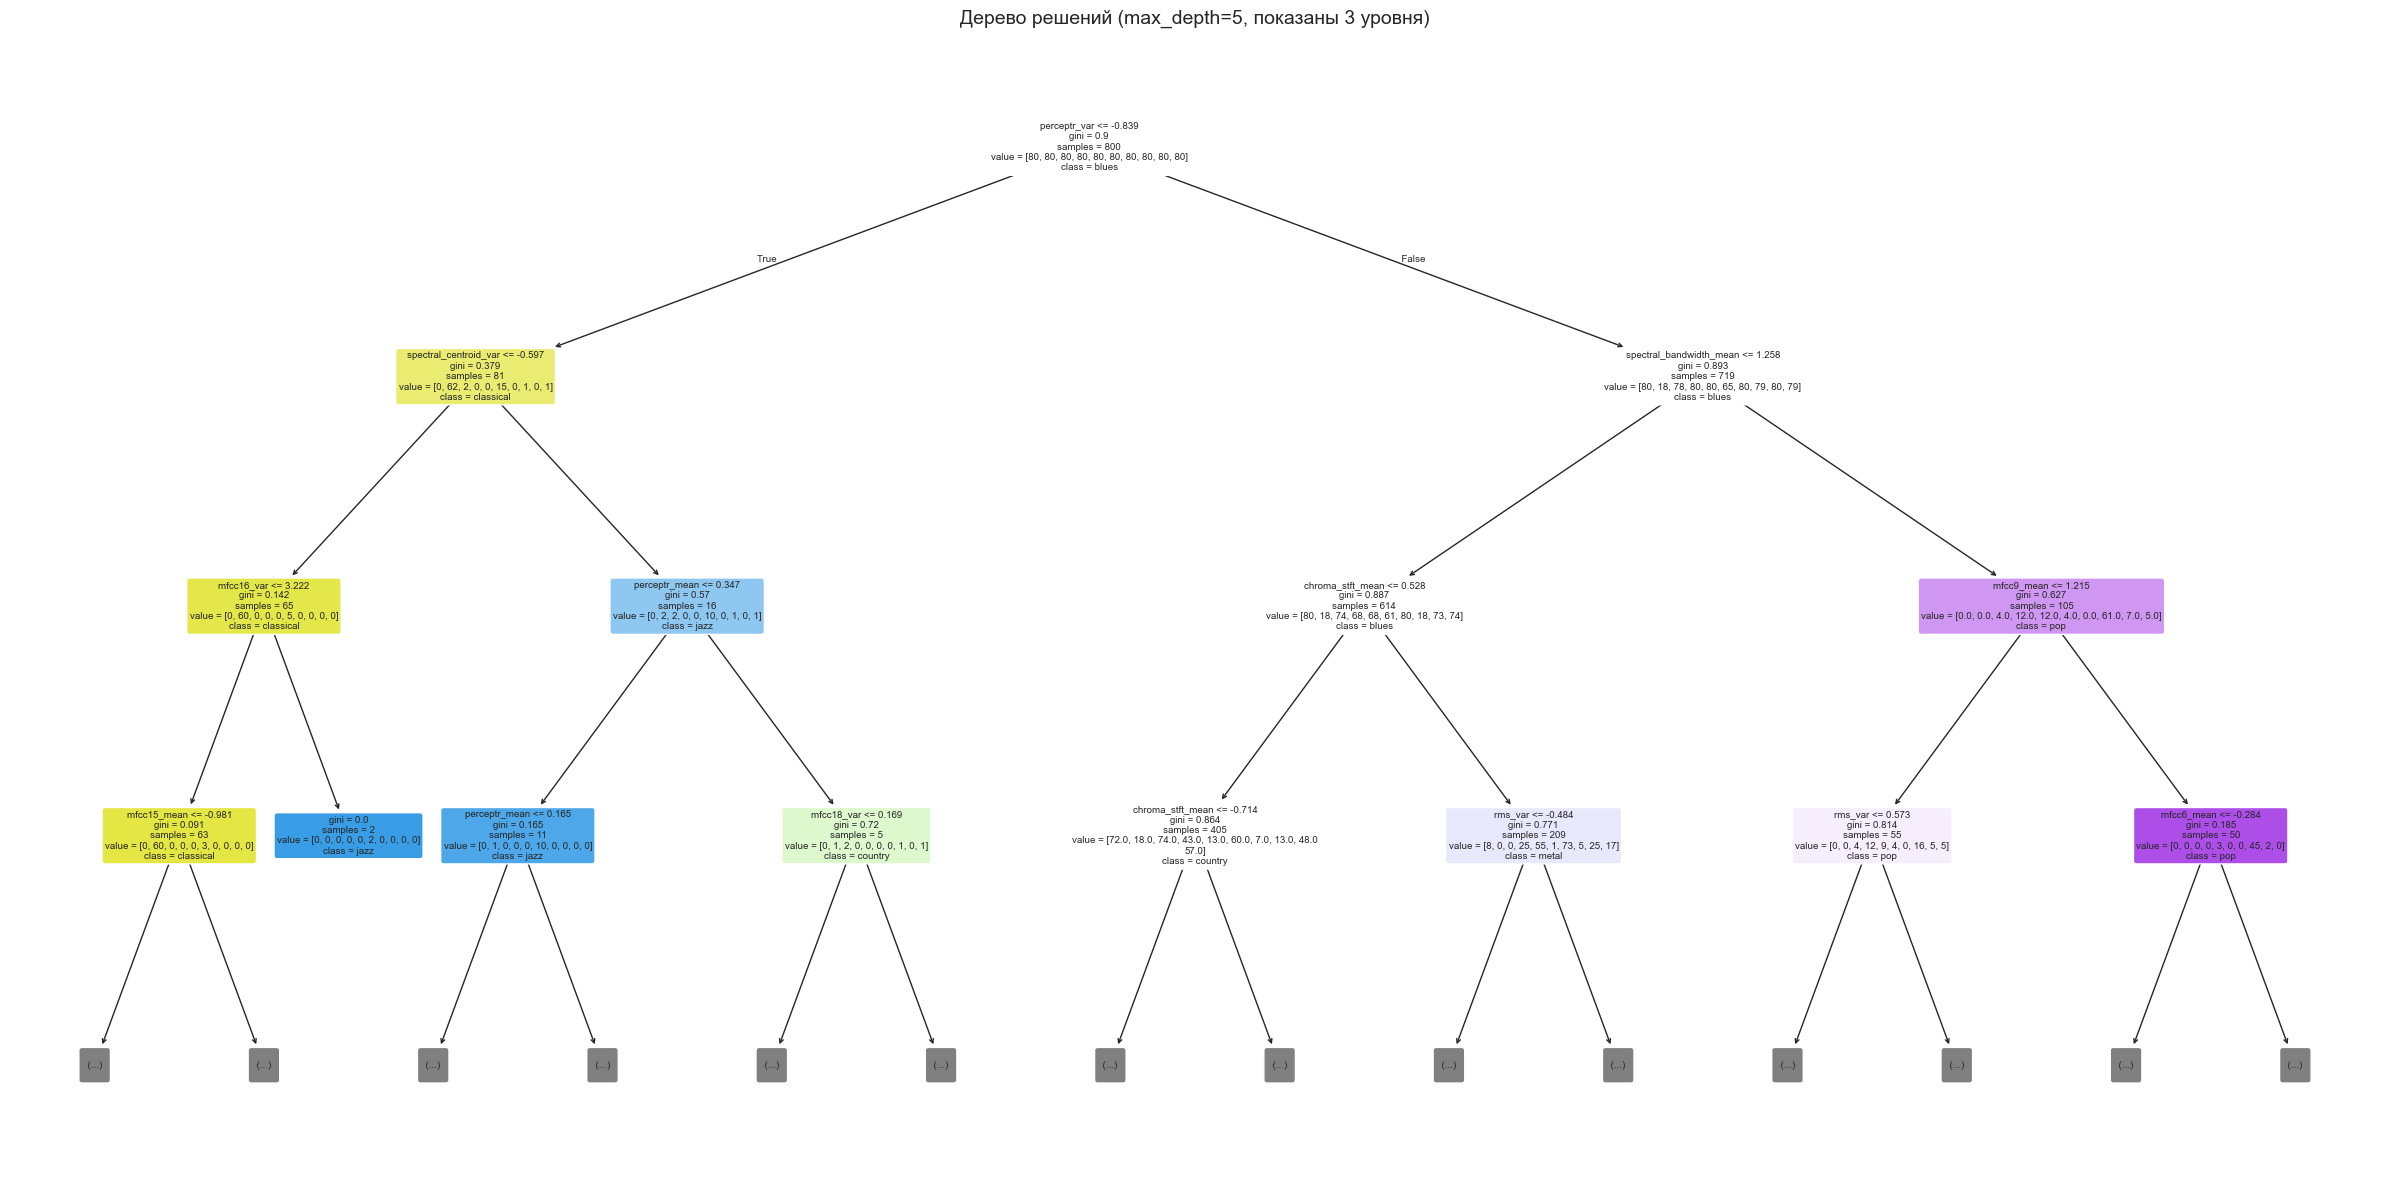

In [36]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_clf, ax=ax, filled=True, rounded=True,
          feature_names=feature_names,
          class_names=le.classes_,
          fontsize=7, max_depth=3)
ax.set_title('Дерево решений (max_depth=5, показаны 3 уровня)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Confusion matrix — дерево решений

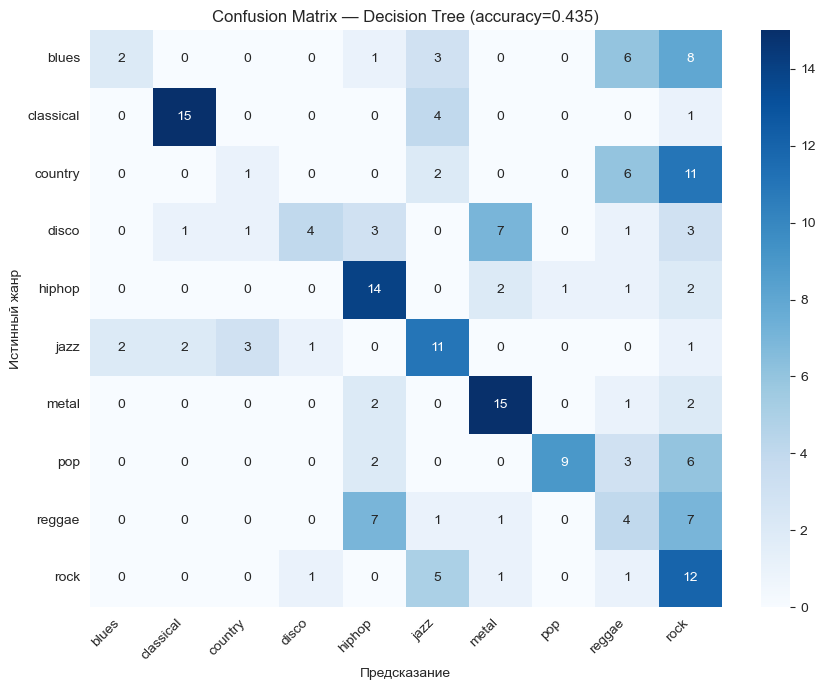

In [6]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — Decision Tree (accuracy={acc_dt:.3f})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Влияние глубины дерева на качество

Исследуем, как параметр `max_depth` влияет на accuracy на обучающей и тестовой выборках. Это наглядно демонстрирует проблему переобучения.

Лучшая глубина: 15, accuracy = 0.5150


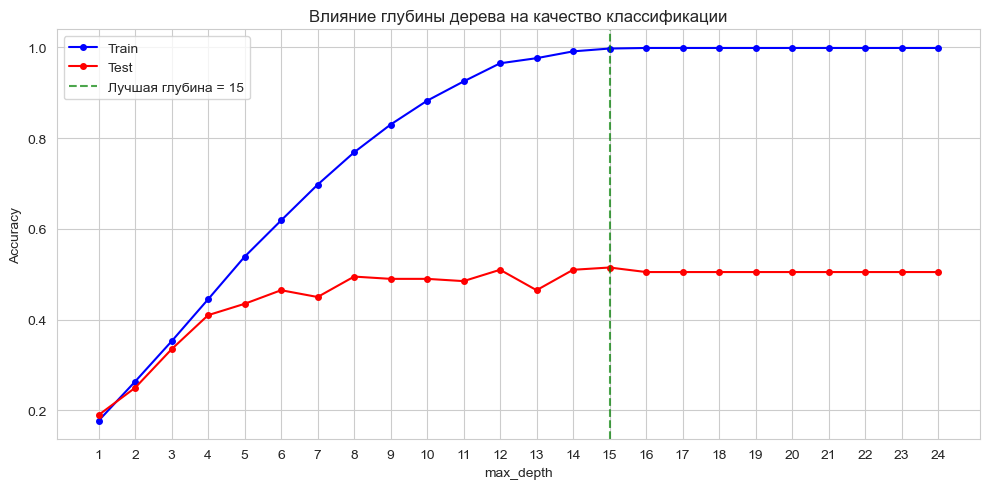

In [37]:
depths = range(1, 25)
train_accs, test_accs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(test_accs)]
print(f'Лучшая глубина: {best_depth}, accuracy = {max(test_accs):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'b-o', markersize=4, label='Train')
ax.plot(depths, test_accs, 'r-o', markersize=4, label='Test')
ax.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7,
           label=f'Лучшая глубина = {best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Влияние глубины дерева на качество классификации')
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

## 5. Случайный лес

Случайный лес объединяет множество деревьев, каждое из которых обучено на бутстрэп-подвыборке с случайным подмножеством признаков. Это существенно повышает качество и устойчивость модели.

In [47]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, max_features='sqrt',
    random_state=42, oob_score=True, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy случайного леса: {acc_rf:.4f}')
print(f'OOB score: {rf_clf.oob_score_:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy случайного леса: 0.6750
OOB score: 0.6887

              precision    recall  f1-score   support

       blues       0.81      0.65      0.72        20
   classical       0.79      0.95      0.86        20
     country       0.81      0.85      0.83        20
       disco       0.47      0.35      0.40        20
      hiphop       0.50      0.60      0.55        20
        jazz       0.76      0.80      0.78        20
       metal       0.76      0.80      0.78        20
         pop       0.71      0.75      0.73        20
      reggae       0.48      0.50      0.49        20
        rock       0.62      0.50      0.56        20

    accuracy                           0.68       200
   macro avg       0.67      0.68      0.67       200
weighted avg       0.67      0.68      0.67       200



### 5.1 Визуализация одного дерева из леса

Каждое дерево в лесе обучено на случайной подвыборке данных и признаков. Покажем структуру одного из 200 деревьев.

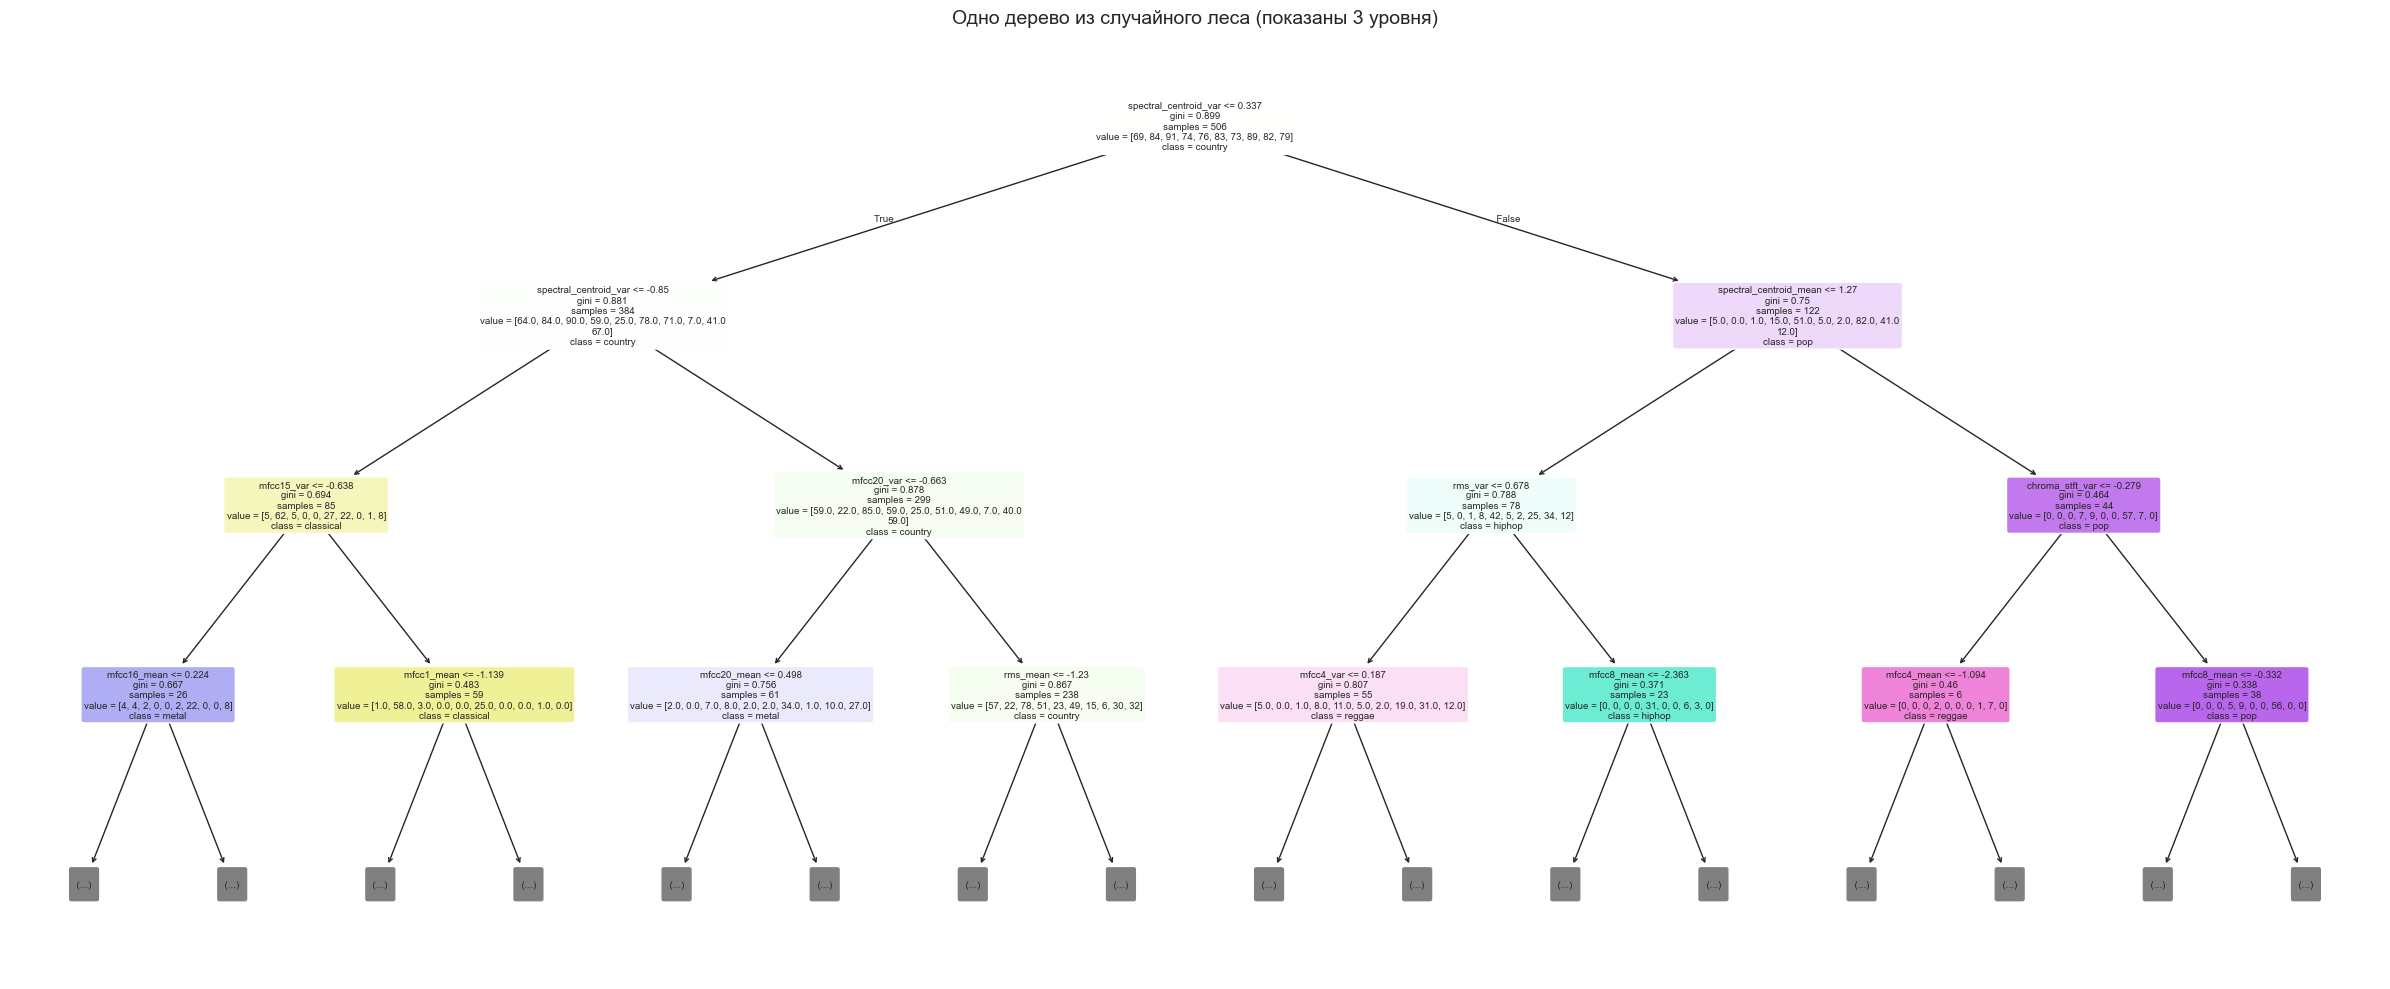

In [49]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(rf_clf.estimators_[0], ax=ax, filled=True, rounded=True,
          feature_names=feature_names,
          class_names=le.classes_,
          fontsize=7, max_depth=3)
ax.set_title('Одно дерево из случайного леса (показаны 3 уровня)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Confusion matrix — случайный лес

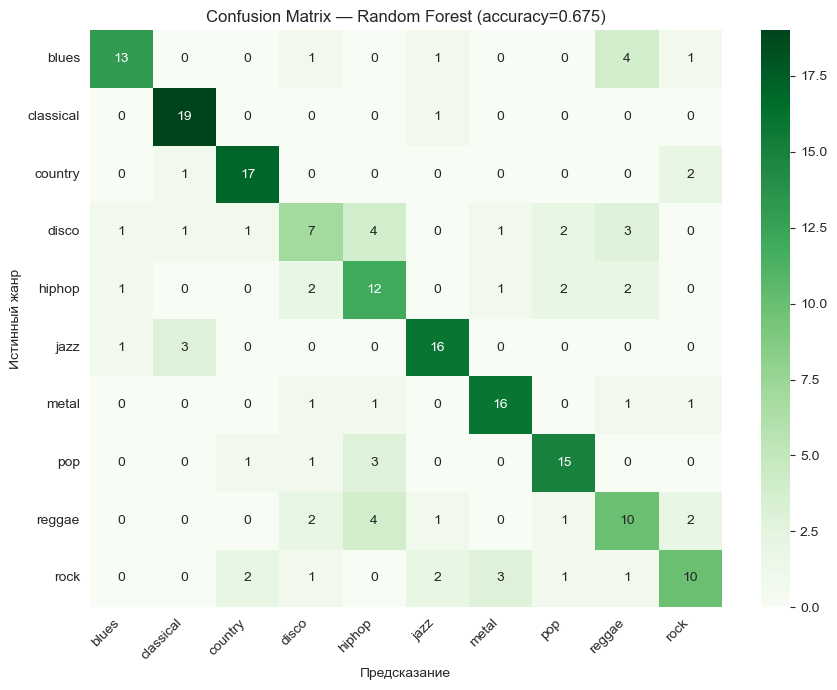

In [50]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — Random Forest (accuracy={acc_rf:.3f})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. ROC-анализ — сравнение моделей

Построим OvR ROC-кривые для обеих моделей и сравним micro-average AUC.

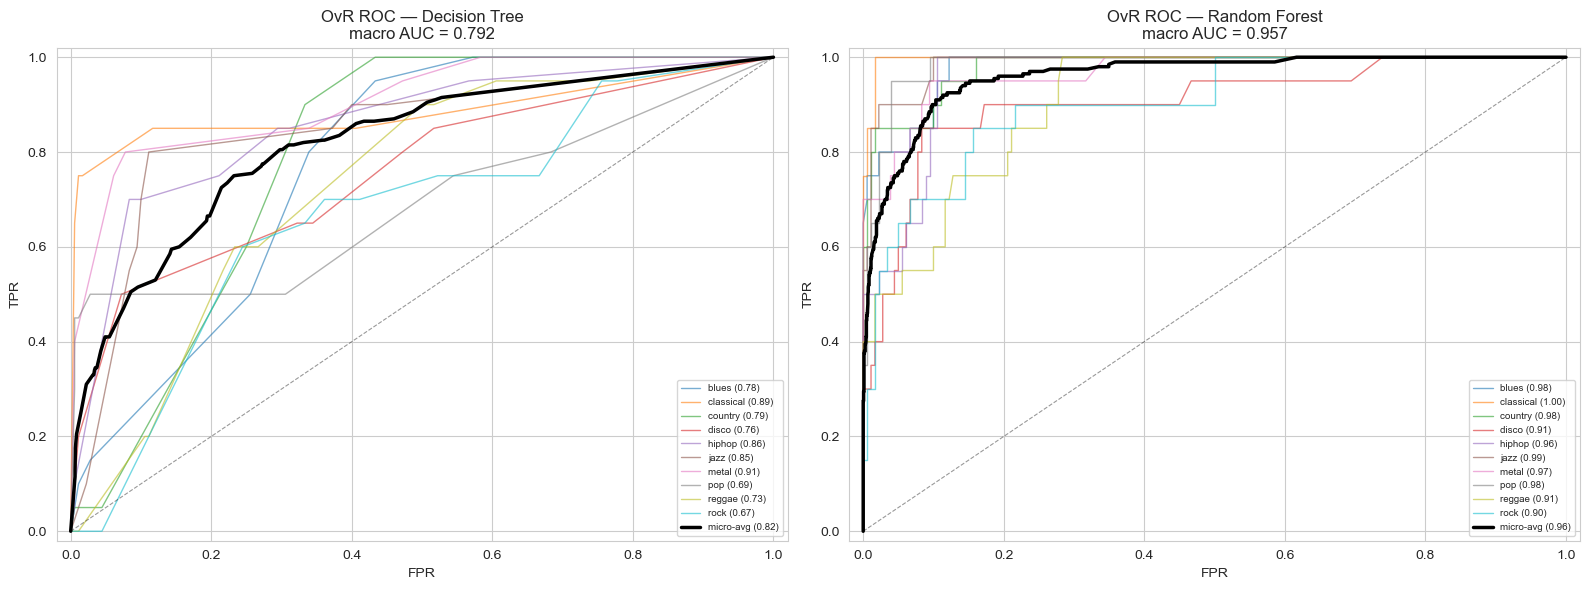

In [11]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_proba, name in zip(axes, [y_proba_dt, y_proba_rf],
                              ['Decision Tree', 'Random Forest']):
    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    
    # Per-class ROC
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    auc_values = []
    for i, color in zip(range(n_classes), colors):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = auc(fpr_i, tpr_i)
        auc_values.append(auc_i)
        ax.plot(fpr_i, tpr_i, color=color, linewidth=1, alpha=0.6,
                label=f'{le.classes_[i]} ({auc_i:.2f})')
    
    ax.plot(fpr_micro, tpr_micro, 'k-', linewidth=2.5,
            label=f'micro-avg ({auc_micro:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'OvR ROC — {name}\nmacro AUC = {np.mean(auc_values):.3f}')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

## 7. Важность признаков (Feature Importance)

Случайный лес позволяет оценить, какие признаки вносят наибольший вклад в классификацию. Важность определяется средним снижением impurity (Gini) при расщеплениях по данному признаку.

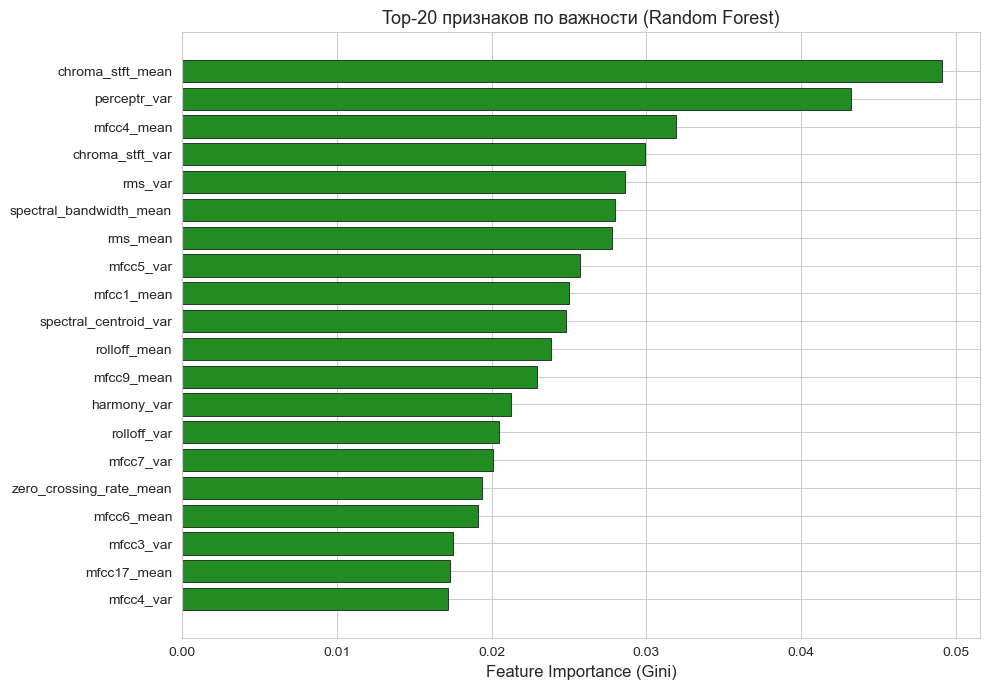

In [51]:
importances = rf_clf.feature_importances_
imp_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
imp_df = imp_df.sort_values('Важность', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Признак'], imp_df['Важность'], color='forestgreen',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top-20 признаков по важности (Random Forest)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Кросс-валидация — сравнение моделей

Сравним дерево решений и случайный лес с помощью стратифицированной 5-fold кросс-валидации.

Decision Tree (max_depth=5): 0.4200 ± 0.0255
Decision Tree (best depth): 0.5120 ± 0.0337
Random Forest (200 деревьев): 0.7110 ± 0.0302


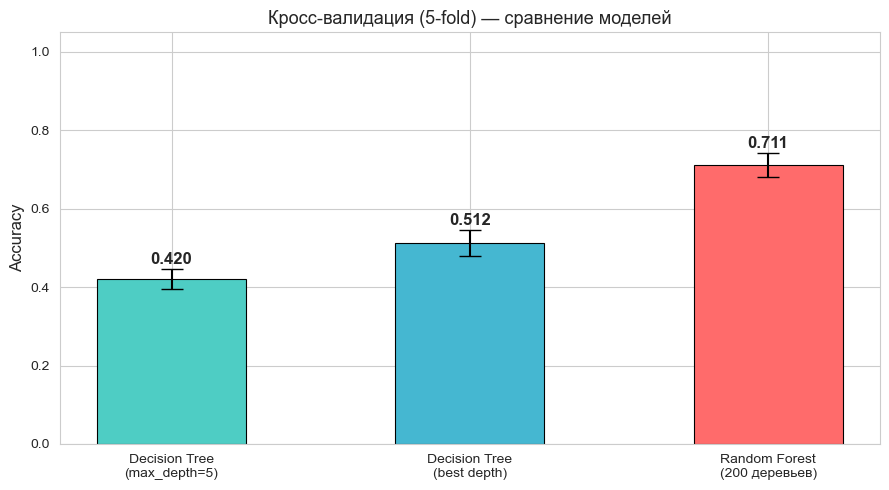

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Decision Tree\n(max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Decision Tree\n(best depth)': DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    'Random Forest\n(200 деревьев)': RandomForestClassifier(n_estimators=200, max_depth=15,
                                                             max_features='sqrt', random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name.replace(chr(10), " ")}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
colors_bar = ['#4ECDC4', '#45B7D1', '#FF6B6B']

bars = ax.bar(names, means, yerr=stds, capsize=8, color=colors_bar,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.005,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Кросс-валидация (5-fold) — сравнение моделей', fontsize=13)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Выводы

1. **Дерево решений** — интерпретируемая модель, но подвержена переобучению. С увеличением `max_depth` accuracy на обучающей выборке растёт до 100%, а на тестовой — падает после оптимальной глубины.

2. **Случайный лес** значительно превосходит одиночное дерево: ансамблирование снижает дисперсию и повышает устойчивость предсказаний.

3. **ROC-анализ** подтверждает преимущество случайного леса: micro/macro AUC существенно выше, что означает лучшее разделение классов.

4. **Confusion matrix** показывает, что случайный лес реже путает близкие жанры (rock/country, disco/pop), с которыми одиночное дерево справляется хуже.

5. **Наиболее важные признаки** для классификации жанров (по убыванию): `chroma_stft_mean` и `chroma_stft_var` (распределение энергии по тональным классам — отлично разделяет, например, classical и metal), `perceptr_var` (изменчивость перцептивной составляющей сигнала), MFCC-коэффициенты (`mfcc4_mean`, `mfcc5_var`, `mfcc1_mean`, `mfcc9_mean` и др. — описывают тембр), энергетические признаки (`rms_mean`, `rms_var`) и спектральные характеристики (`spectral_bandwidth_mean`, `spectral_centroid_var`, `rolloff_mean`). Важность распределена относительно равномерно: топовый признак даёт лишь ~5% вклада, что говорит о том, что классификация жанров опирается на совокупность признаков, а не на 1–2 доминирующих. Примечательно, что **топ-2 признака (`chroma_stft_mean`, `perceptr_var`) совпадают с топом весов логистической регрессии из lab9** — две принципиально разные модели (линейная на основе MSE/CE и нелинейный ансамбль на основе Gini) независимо подтверждают, что эти признаки наиболее информативны для жанровой классификации GTZAN.

6. **Кросс-валидация** подтвердила стабильность результатов: случайный лес показывает более высокую и стабильную accuracy по сравнению с одиночным деревом.